# Visualize Saved Logit Lens Training Results

This notebook loads the newest saved probe-head checkpoint from `results/`, reconstructs the learned heads, loads Pile-10k, and visualizes how each block's mapped output compares with the model's final output.

In [87]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import transformer_lens as tl
from datasets import load_dataset
from transformer_lens import HookedTransformer

device = "cuda:1" if torch.cuda.is_available() else "cpu"
results_dir = Path("results")
checkpoint_patterns = ("probe_heads_*.pt", "joint_heads_*.pt")

def latest_checkpoint(results_dir=results_dir, patterns=checkpoint_patterns):
    candidates = []
    for pattern in patterns:
        candidates.extend(results_dir.glob(pattern))

    if not candidates:
        candidates = [
            path for path in results_dir.glob("*.pt")
            if not path.name.startswith("distance_to_final_")
        ]

    if not candidates:
        raise FileNotFoundError(
            "No saved training checkpoint found. Run the training notebook first; "
            "it should create files like results/probe_heads_YYYYMMDD_HHMMSS.pt."
        )

    return max(candidates, key=lambda path: path.stat().st_mtime)

checkpoint_path = latest_checkpoint()
checkpoint = torch.load(checkpoint_path, map_location="cpu")

print(f"Using device: {device}")
print(f"Loaded checkpoint: {checkpoint_path}")
print(f"Run name: {checkpoint.get('run_name')}")
print(f"Probe input normalization: {checkpoint.get('probe_input_normalization', 'unknown')}")

Using device: cuda:1
Loaded checkpoint: results/probe_heads_20260508_231020.pt
Run name: probe_heads
Probe input normalization: raw_resid_post


In [88]:
model_name = checkpoint.get("model_name") or "pythia-160M"
model: HookedTransformer = tl.HookedTransformer.from_pretrained(model_name, device=device)
model.eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    print("Loaded saved base-model state from checkpoint.")

num_model_blocks = int(checkpoint.get("num_model_blocks", len(model.blocks)))
unembedding_matrices = torch.nn.ModuleList([
    torch.nn.Linear(model.cfg.d_model, model.cfg.d_vocab, bias=True)
    for _ in range(num_model_blocks + 1)
])
unembedding_matrices.load_state_dict(checkpoint["unembedding_matrices_state_dict"])
unembedding_matrices.to(device)
unembedding_matrices.eval()
final_unembedding = unembedding_matrices[-1]

print(f"Loaded model: {model_name}")
print(f"Number of block heads: {num_model_blocks}")
print(f"d_model={model.cfg.d_model}, d_vocab={model.cfg.d_vocab}")

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 13120.69it/s]


Loaded pretrained model pythia-14m into HookedTransformer
Loaded model: pythia-14m
Number of block heads: 6
d_model=128, d_vocab=50304


In [89]:
ds = load_dataset("NeelNanda/pile-10k")

context_window = int(checkpoint.get("context_window", 10))
num_text_samples = min(int(checkpoint.get("num_text_samples", 1000)), len(ds["train"]))
rng = np.random.default_rng(seed=0)
randoms = rng.choice(len(ds["train"]), size=num_text_samples, replace=False)

chunks = []
for dataset_idx in randoms:
    text = ds["train"][int(dataset_idx)]["text"]
    encoded = model.tokenizer.encode(text)
    if len(encoded) < context_window + 1:
        continue

    encoded = torch.tensor(encoded, dtype=torch.long)
    chunks.append(encoded.unfold(0, context_window + 1, 1))

if not chunks:
    raise ValueError("No token windows were created. Try lowering context_window or sampling more texts.")

tokens = torch.cat(chunks, dim=0).contiguous()

print(f"Loaded Pile-10k split: {ds['train'].num_rows} rows")
print(f"Sampled text rows: {num_text_samples}")
print(f"Context window: {context_window}")
print(f"Token windows: {tuple(tokens.shape)}")
print("\nPreview text:")
print(ds["train"][int(randoms[0])]["text"][:600])

Loaded Pile-10k split: 10000 rows
Sampled text rows: 1000
Context window: 10
Token windows: (1419088, 11)

Preview text:
Social media giants accused of abusing market power

by Don Groves

Here is a summary of some of the submissions to the Australian Competition and Consumer Commission (ACCC) digital platforms inquiry.

Facebook and Google are abusing their monopoly powers, which negatively impacts traditional media and harms consumers, are spreading misinformation and are not preventing the misuse or theft of users' data, according to some submissions to the ACCC.

News Corp Australia told the inquiry the digital platforms are subverting access to online subscription and advertising revenues, which is "undermi


## Shown here is the crossentropy loss by training step for the thing...

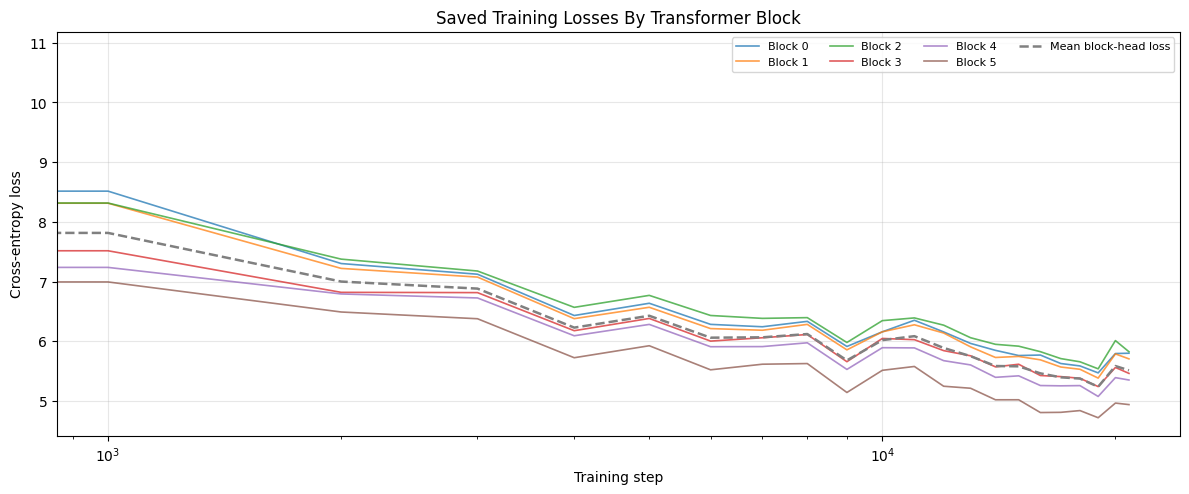

Saved training steps: 20823
Last final loss: 4.9358
Last mean block loss: 5.5122
Last block loss sum: 33.0729
Last block losses:
  block 00: 5.7983
  block 01: 5.7037
  block 02: 5.8232
  block 03: 5.4605
  block 04: 5.3496
  block 05: 4.9376


In [90]:
training_history = checkpoint.get("training_history", [])
plot_every = 1000

if not training_history:
    print("No training_history was saved in this checkpoint.")
else:
    xs = np.arange(len(training_history))
    plot_idx = np.unique(np.r_[np.arange(0, len(xs), plot_every), len(xs) - 1])
    final_losses = np.array([entry.get("final_loss", np.nan) for entry in training_history], dtype=float)
    block_lists = [entry.get("block_losses", []) for entry in training_history]
    block_losses = np.full((len(block_lists), max(map(len, block_lists))), np.nan)
    for step, losses in enumerate(block_lists):
        block_losses[step, :len(losses)] = losses

    block_loss_means = np.nanmean(block_losses, axis=1)
    block_loss_sums = np.nansum(block_losses, axis=1)
    total_losses = np.array([entry.get("total_loss", np.nan) for entry in training_history], dtype=float)

    plt.figure(figsize=(12, 5))
    for layer, losses in enumerate(block_losses.T):
        plt.plot(xs[plot_idx], losses[plot_idx], alpha=0.75, linewidth=1.2, label=f"Block {layer}")
    # plt.plot(xs[plot_idx], final_losses[plot_idx], color="black", label="Final head loss", linewidth=2.2)
    plt.plot(xs[plot_idx], block_loss_means[plot_idx], color="gray", linestyle="--", label="Mean block-head loss", linewidth=1.8)
    if not np.isnan(total_losses).all():
        plt.plot(xs[plot_idx], total_losses[plot_idx], label="Total loss", alpha=0.6)
    plt.title("Saved Training Losses By Transformer Block")
    plt.xlabel("Training step")
    plt.ylabel("Cross-entropy loss")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=4, fontsize=8)
    plt.tight_layout()
    plt.xscale("log")
    plt.show()

    print(f"Saved training steps: {len(training_history)}")
    print(f"Last final loss: {final_losses[-1]:.4f}")
    print(f"Last mean block loss: {block_loss_means[-1]:.4f}")
    print(f"Last block loss sum: {block_loss_sums[-1]:.4f}")
    print("Last block losses:")
    for layer, loss_value in enumerate(block_losses[-1]):
        print(f"  block {layer:02d}: {loss_value:.4f}")

## Shown below is a plot of the cross-entropy between the predicted values from each lens after each transformer block, and the true next token.

### As can be seen, the tuned lens gives a better cross-entropy loss than the model's final unembed layer.

torch.Size([2000, 10])


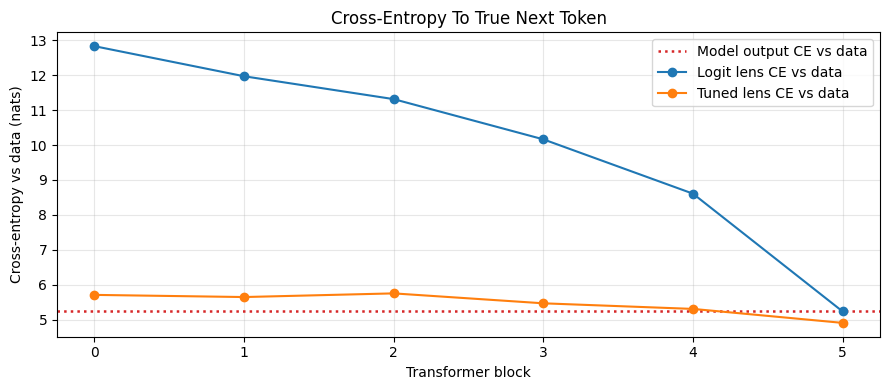

Model output cross-entropy vs data: 5.2382 nats
Final-layer logit-lens cross-entropy vs data: 5.2382 nats
Final-layer tuned-lens cross-entropy vs data: 4.9106 nats


In [91]:
ce_sample_size = min(2000, tokens.shape[0])
sample_idx = torch.tensor(
    np.random.default_rng(seed=1).choice(tokens.shape[0], size=ce_sample_size, replace=False),
    dtype=torch.long,
)
sample_inputs = tokens[sample_idx, :-1].to(device)
sample_targets = tokens[sample_idx, 1:].to(device)
print(sample_inputs.shape)

probe_input_normalization = checkpoint.get("probe_input_normalization", "raw_resid_post")
apply_ln_to_probe_inputs = probe_input_normalization == "ln_final_resid_post"

with torch.no_grad():
    _, sample_cache = model.run_with_cache(
        sample_inputs,
        names_filter=lambda name: name.endswith("hook_resid_post"),
        return_type=None,
    )
    final_resid = sample_cache["resid_post", num_model_blocks - 1]
    final_logits = model.unembed(model.ln_final(final_resid))

    def ce_by_pos(logits):
        return F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            sample_targets.reshape(-1),
            reduction="none",
        ).reshape_as(sample_targets).cpu()

    final_data_ce_by_pos = ce_by_pos(final_logits)

    def tuned_lens_logits(layer):
        block_resid = sample_cache["resid_post", layer]
        if apply_ln_to_probe_inputs:
            block_resid = model.ln_final(block_resid)
        return unembedding_matrices[layer](block_resid)

    logit_lens_ce_by_pos = torch.stack([
        ce_by_pos(model.unembed(model.ln_final(sample_cache["resid_post", layer])))
        for layer in range(num_model_blocks)
    ])
    tuned_lens_ce_by_pos = torch.stack([
        ce_by_pos(tuned_lens_logits(layer))
        for layer in range(num_model_blocks)
    ])

logit_lens_ce = logit_lens_ce_by_pos.mean(dim=(1, 2)).numpy()
tuned_lens_ce = tuned_lens_ce_by_pos.mean(dim=(1, 2)).numpy()
final_data_ce = final_data_ce_by_pos.mean().item()
layers = np.arange(num_model_blocks)

fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(final_data_ce, color="tab:red", linestyle=":", linewidth=1.8, label="Model output CE vs data")
ax.plot(layers, logit_lens_ce, marker="o", label="Logit lens CE vs data")
ax.plot(layers, tuned_lens_ce, marker="o", label="Tuned lens CE vs data")
ax.set_title("Cross-Entropy To True Next Token")
ax.set_xlabel("Transformer block")
ax.set_ylabel("Cross-entropy vs data (nats)")
ax.grid(True, alpha=0.3)
ax.legend()
# plt.xscale("log")
plt.tight_layout()
plt.show()

print(f"Model output cross-entropy vs data: {final_data_ce:.4f} nats")
print(f"Final-layer logit-lens cross-entropy vs data: {logit_lens_ce[-1]:.4f} nats")
print(f"Final-layer tuned-lens cross-entropy vs data: {tuned_lens_ce[-1]:.4f} nats")

## Functions that print the decoded logit lens and tuned lens outputs

In [92]:
def tuned_lens_outputs(text, unembedding_matrices, model, num_model_blocks, final_unembedding=None):
    assert len(unembedding_matrices) == num_model_blocks + 1
    final_head = unembedding_matrices[-1]
    if final_unembedding is not None:
        assert final_unembedding is final_head

    with torch.no_grad():
        tokens = model.to_tokens(text)
        _, cache = model.run_with_cache(tokens)
        print(f"Testing block heads plus final head for input: '{text}'")
        for i in range(num_model_blocks):
            block_output = cache["resid_post", i]
            output = unembedding_matrices[i](block_output)
            assert output.shape == (*tokens.shape, model.cfg.d_vocab)

            selected_output = output.argmax(dim=-1).cpu().numpy()
            output_text = model.tokenizer.decode(selected_output[0])
            print(f"Block head {i}: {output_text}")

        final_block = cache["resid_post", num_model_blocks - 1]
        final_logits = final_head(model.ln_final(final_block))
        assert final_logits.shape == (*tokens.shape, model.cfg.d_vocab)
        final_output = final_logits.argmax(dim=-1).cpu().numpy()
        final_text = model.tokenizer.decode(final_output[0])

        model_logits = model.unembed(model.ln_final(final_block))
        model_output = model_logits.argmax(dim=-1).cpu().numpy()
        model_text = model.tokenizer.decode(model_output[0])
        print(f"Final head: {final_text}")
        print(f"Model unembed: {model_text}")


In [93]:
def logit_lens_outputs(text, model, unembedding_matrices, final_unembedding=None):
    num_block_heads = model.cfg.n_layers
    assert len(unembedding_matrices) == num_block_heads + 1
    final_head = unembedding_matrices[-1]
    if final_unembedding is not None:
        assert final_unembedding is final_head

    with torch.no_grad():
        tokens = model.to_tokens(text)
        _, cache = model.run_with_cache(tokens)
        print(f"Testing block heads plus final head for input: '{text}'")
        for layer in range(num_block_heads):
            block_output = cache["resid_post", layer]
            block_logits = unembedding_matrices[layer](model.ln_final(block_output))
            selected_output = block_logits.argmax(dim=-1).cpu().numpy()
            output_text = model.tokenizer.decode(selected_output[0])
            print(f"Block head {layer}: {output_text}")

        final_block = cache["resid_post", num_block_heads - 1]
        final_logits = model.unembed(model.ln_final(final_block))
        final_output = final_logits.argmax(dim=-1).cpu().numpy()
        final_text = model.tokenizer.decode(final_output[0])
        print(f"Final head: {final_text}")

In [94]:
logit_lens_outputs("The president has many responsibilities, which include, but aren't limited to:", model, unembedding_matrices, final_unembedding)

Testing block heads plus final head for input: 'The president has many responsibilities, which include, but aren't limited to:'
Block head 0:  district of been years of but is a but it't want to be https
Block head 1:  district's been of of but is the but he't know to the

Block head 2:  is's been of of and is the the the't want to the

Block head 3: 's’ been of to and is a but not't going to the

Block head 4:  is's been of to and is a as not't going to a

Block head 5:  expression's been of to but has a for not't, to your “
Final head: 
 said been of. and is the for not't, to,



In [95]:
tuned_lens_outputs("The president has many responsibilities, which include, but aren't limited to:", unembedding_matrices, model, num_model_blocks, final_unembedding)

Testing block heads plus final head for input: 'The president has many responsibilities, which include, but aren't limited to:'
Block head 0:  first. been of of and is the and the't be to the

Block head 1:  first of been of of and is the the the't have to the

Block head 2: 
. been of of and is the the the't in to the

Block head 3: 's. a of to and is a a not't the to the

Block head 4: 
's been of, and is a
 not't. to the

Block head 5: 
's been of, and is a in not't, to,

Final head:  expression's been of to but has a for not't, to your “
Model unembed: 
 said been of. and is the for not't, to,

